 1.Importing the Dependencies

In [24]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Date/time handling
import datetime as dt

# Ignore warnings (optional)
import warnings
warnings.filterwarnings("ignore")


2. Data Loading and Understanding

In [25]:

import pandas as pd

# Chicago Crime dataset - pull from City of Chicago API
# Filtering: crimes from 2019 onwards (~5 years of data)
url = "https://data.cityofchicago.org/resource/ijzp-q8t2.csv?$where=date>'2019-01-01T00:00:00'&$limit=500000"

# Read into pandas
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()



Dataset shape: (500000, 22)
Columns: ['id', 'case_number', 'date', 'block', 'iucr', 'primary_type', 'description', 'location_description', 'arrest', 'domestic', 'beat', 'district', 'ward', 'community_area', 'fbi_code', 'x_coordinate', 'y_coordinate', 'year', 'updated_on', 'latitude', 'longitude', 'location']


,id,case_number,date,block,iucr,primary_type,description,location_description,arrest,domestic,...,ward,community_area,fbi_code,x_coordinate,y_coordinate,year,updated_on,latitude,longitude,location
0,14004364,JJ458530,2025-10-15T00:00:00.000,040XX N LINCOLN AVE,1130,DECEPTIVE PRACTICE,FRAUD OR CONFIDENCE GAME,PARKING LOT / GARAGE (NON RESIDENTIAL),False,False,...,47.0,5.0,11,NaN,NaN,2025,2025-10-22T15:42:01.000,NaN,NaN,NaN
1,13998259,JJ452257,2025-10-15T00:00:00.000,035XX S HONORE ST,1320,CRIMINAL DAMAGE,TO VEHICLE,RESIDENCE - YARD (FRONT / BACK),False,False,...,12.0,59.0,14,1164597.0,1881179.0,2025,2025-10-22T15:42:01.000,41.829567,-87.671601,"\n, \n(41.82956688, -87.671600615)"
2,14004227,JJ458503,2025-10-15T00:00:00.000,029XX N SHERIDAN RD,1242,DECEPTIVE PRACTICE,COMPUTER FRAUD,RESIDENCE,False,False,...,44.0,6.0,11,NaN,NaN,2025,2025-10-22T15:42:01.000,NaN,NaN,NaN
3,13999795,JJ454236,2025-10-15T00:00:00.000,060XX S BISHOP ST,1153,DECEPTIVE PRACTICE,FINANCIAL IDENTITY THEFT OVER $ 300,RESIDENCE,False,False,...,16.0,67.0,11,1167699.0,1864694.0,2025,2025-10-22T15:42:01.000,41.784264,-87.660693,"\n, \n(41.784264073, -87.660692809)"
4,14000982,JJ454683,2025-10-15T00:00:00.000,009XX W HURON ST,1320,CRIMINAL DAMAGE,TO VEHICLE,STREET,False,False,...,27.0,24.0,14,1169881.0,1905076.0,2025,2025-10-22T15:42:01.000,41.895029,-87.651517,"\n, \n(41.895028832, -87.651517456)"


In [26]:
# Convert 'date' column to datetime
df['date'] = pd.to_datetime(df['date'])

# Extract features
df['hour'] = df['date'].dt.hour
df['day_of_week'] = df['date'].dt.day_name()
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year

# Quick check
df[['date', 'hour', 'day_of_week', 'month', 'year']].head()


,date,hour,day_of_week,month,year
0,2025-10-15,0,Wednesday,10,2025
1,2025-10-15,0,Wednesday,10,2025
2,2025-10-15,0,Wednesday,10,2025
3,2025-10-15,0,Wednesday,10,2025
4,2025-10-15,0,Wednesday,10,2025


Missing Values Overview

In [27]:
df.isnull().sum().sort_values(ascending=False).head(10)


,0
location_description,2102
longitude,2086
latitude,2086
y_coordinate,2086
location,2086
x_coordinate,2086
ward,1
community_area,1
id,0
arrest,0


Exploratory Data Analysis (EDA)

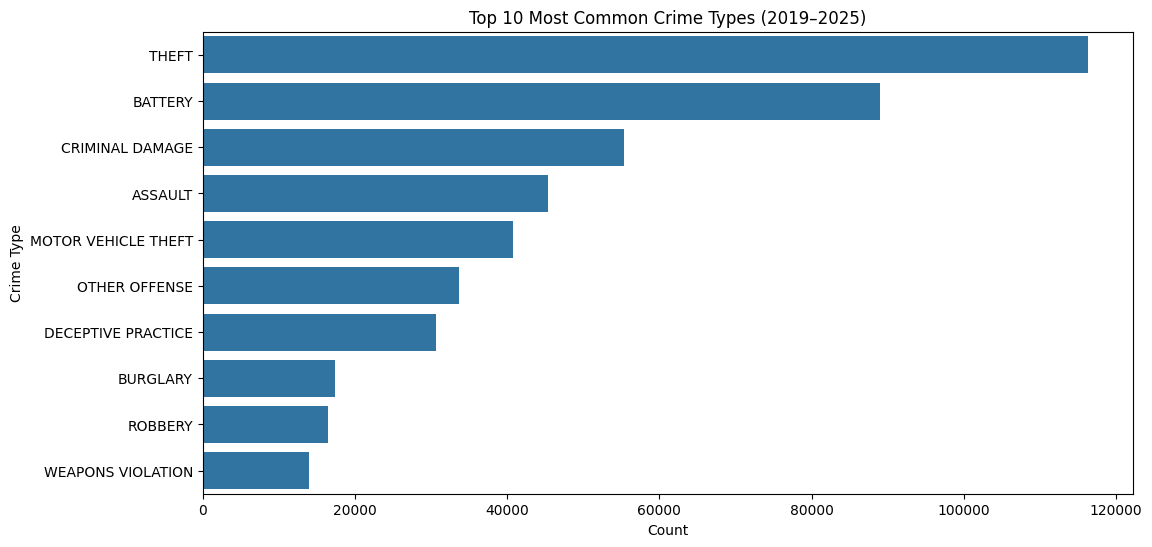

In [28]:
plt.figure(figsize=(12,6))
sns.countplot(data=df, y='primary_type', order=df['primary_type'].value_counts().head(10).index)
plt.title("Top 10 Most Common Crime Types (2019–2025)")
plt.xlabel("Count")
plt.ylabel("Crime Type")
plt.show()


Define a “Hotspot”

In [29]:
# Count crimes by community area
crime_counts = df['community_area'].value_counts()

# Define hotspots as top 10% areas
threshold = crime_counts.quantile(0.90)
hotspots = crime_counts[crime_counts >= threshold].index

# Create hotspot label (1 = hotspot, 0 = not)
df['hotspot'] = df['community_area'].apply(lambda x: 1 if x in hotspots else 0)

df[['community_area','hotspot']].head()


,community_area,hotspot
0,5.0,0
1,59.0,0
2,6.0,0
3,67.0,0
4,24.0,1


In [30]:
# Aggregate daily crime counts
daily_counts = df.groupby('date').size().reset_index(name='crime_count')
daily_counts.head()


,date,crime_count
0,2023-10-17 19:30:00,1
1,2023-10-17 19:31:00,2
2,2023-10-17 19:37:00,1
3,2023-10-17 19:40:00,2
4,2023-10-17 19:45:00,1


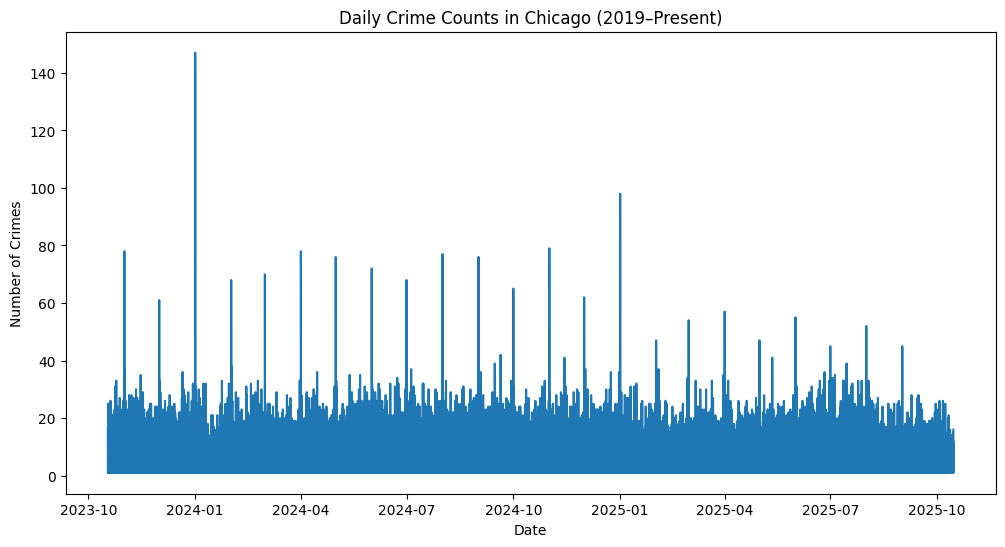

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(daily_counts['date'], daily_counts['crime_count'])
plt.title("Daily Crime Counts in Chicago (2019–Present)")
plt.xlabel("Date")
plt.ylabel("Number of Crimes")
plt.show()


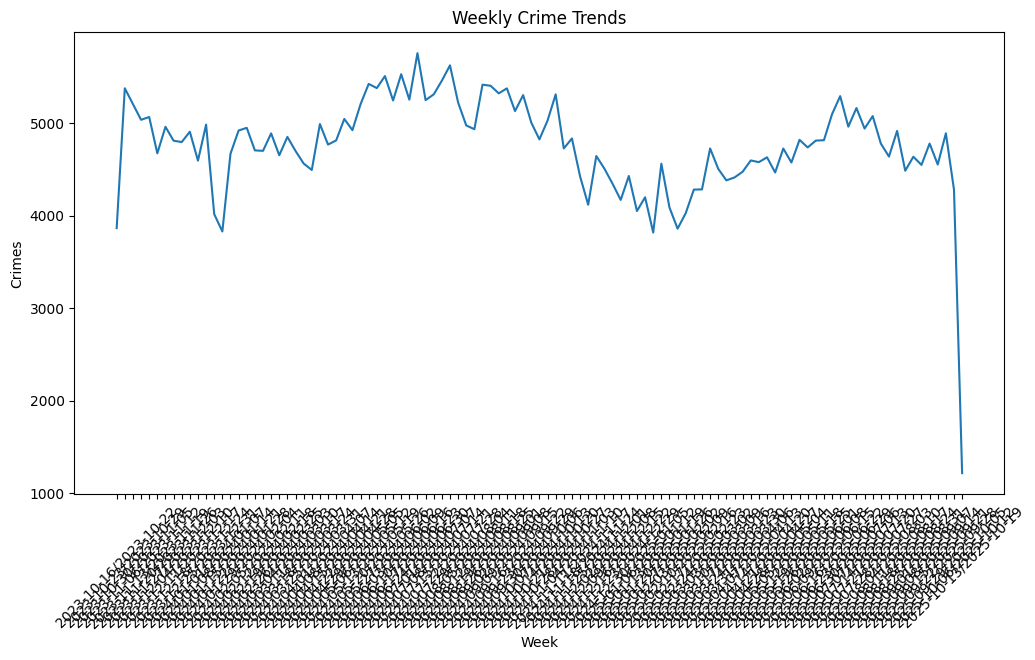

In [32]:
df['week'] = pd.to_datetime(df['date']).dt.to_period('W')
weekly_counts = df.groupby('week').size().reset_index(name='crime_count')

plt.figure(figsize=(12,6))
plt.plot(weekly_counts['week'].astype(str), weekly_counts['crime_count'])
plt.title("Weekly Crime Trends")
plt.xlabel("Week")
plt.ylabel("Crimes")
plt.xticks(rotation=45)
plt.show()


Overview of the Data

In [33]:
# Basic info
df.info()

# Summary statistics
df.describe()

# Check for missing values
df.isnull().sum().sort_values(ascending=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 27 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   id                    500000 non-null  int64         
 1   case_number           500000 non-null  object        
 2   date                  500000 non-null  datetime64[ns]
 3   block                 500000 non-null  object        
 4   iucr                  500000 non-null  object        
 5   primary_type          500000 non-null  object        
 6   description           500000 non-null  object        
 7   location_description  497898 non-null  object        
 8   arrest                500000 non-null  bool          
 9   domestic              500000 non-null  bool          
 10  beat                  500000 non-null  int64         
 11  district              500000 non-null  int64         
 12  ward                  499999 non-null  float64       
 13 

,0
location_description,2102
x_coordinate,2086
y_coordinate,2086
latitude,2086
longitude,2086
location,2086
ward,1
community_area,1
date,0
case_number,0


Distribution of Crimes Over Time

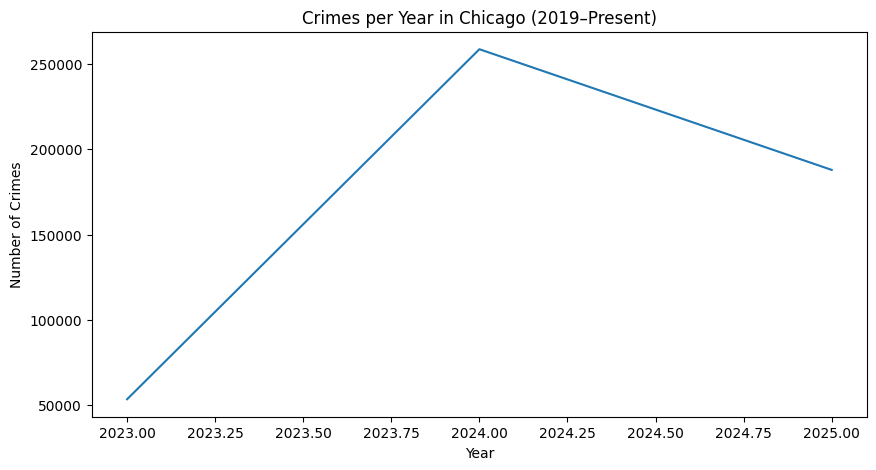

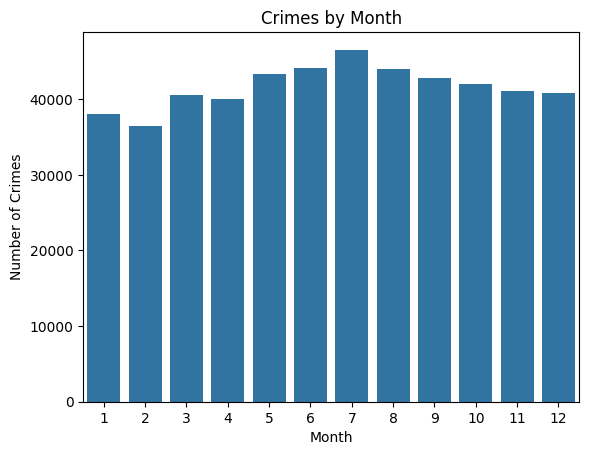

In [34]:
# Crimes per year
df['year'] = pd.to_datetime(df['date']).dt.year
yearly_counts = df['year'].value_counts().sort_index()
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_counts.index, y=yearly_counts.values)
plt.title("Crimes per Year in Chicago (2019–Present)")
plt.xlabel("Year")
plt.ylabel("Number of Crimes")
plt.show()

# Crimes per month
df['month'] = pd.to_datetime(df['date']).dt.month
monthly_counts = df['month'].value_counts().sort_index()
sns.barplot(x=monthly_counts.index, y=monthly_counts.values)
plt.title("Crimes by Month")
plt.xlabel("Month")
plt.ylabel("Number of Crimes")
plt.show()


Top Crime Types

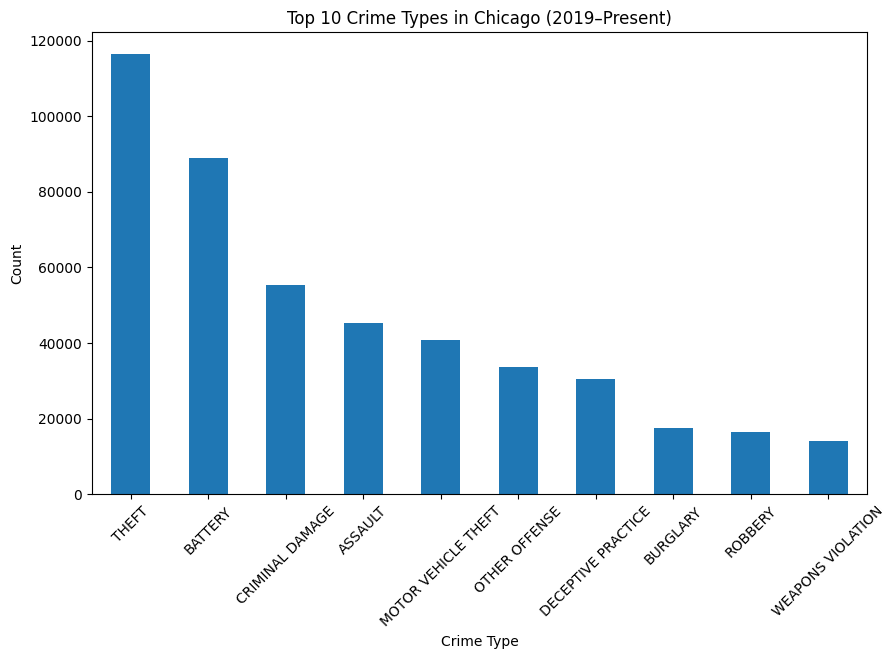

In [35]:
plt.figure(figsize=(10,6))
df['primary_type'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Crime Types in Chicago (2019–Present)")
plt.xlabel("Crime Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


Crimes by Location Type

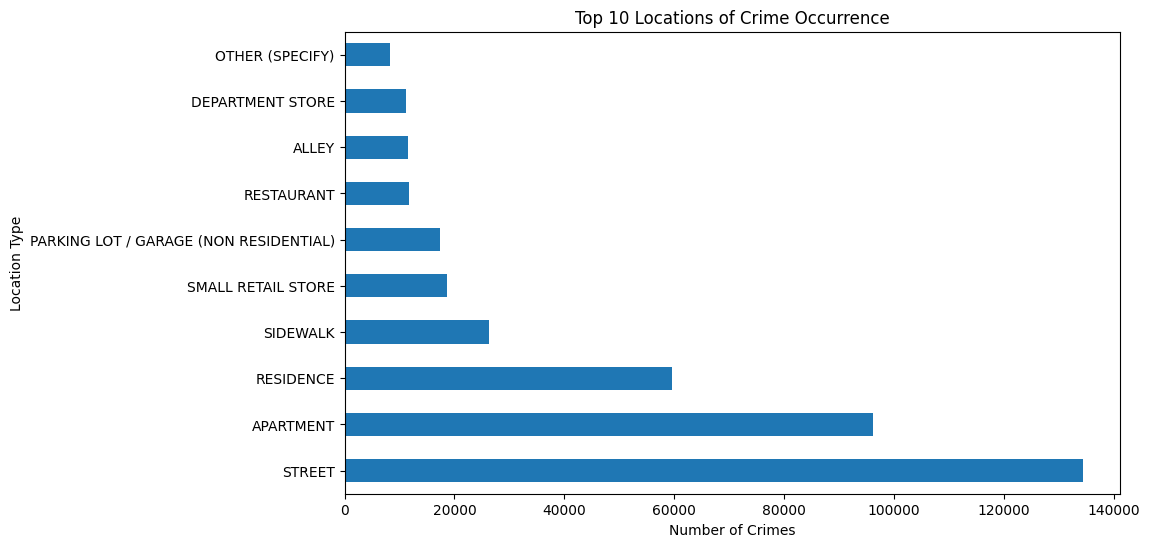

In [36]:
plt.figure(figsize=(10,6))
df['location_description'].value_counts().head(10).plot(kind='barh')
plt.title("Top 10 Locations of Crime Occurrence")
plt.xlabel("Number of Crimes")
plt.ylabel("Location Type")
plt.show()




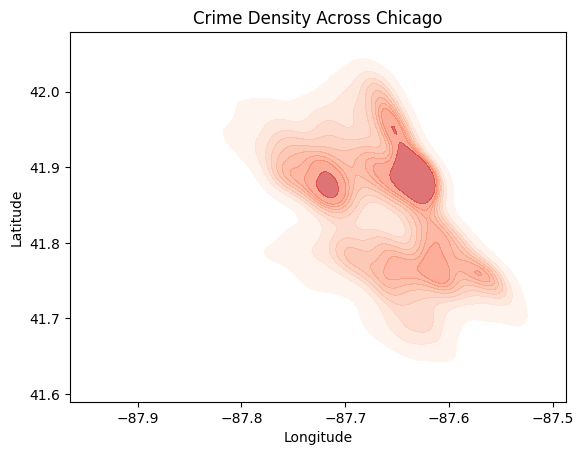

In [37]:
sns.kdeplot(
    data=df.sample(10000),
    x='longitude',
    y='latitude',
    fill=True,
    cmap='Reds',
    alpha=0.6
)
plt.title("Crime Density Across Chicago")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


Arrest and Domestic Patterns

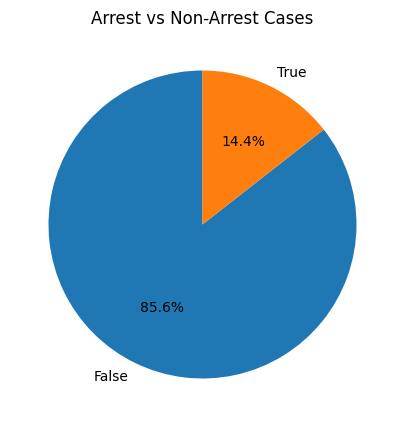

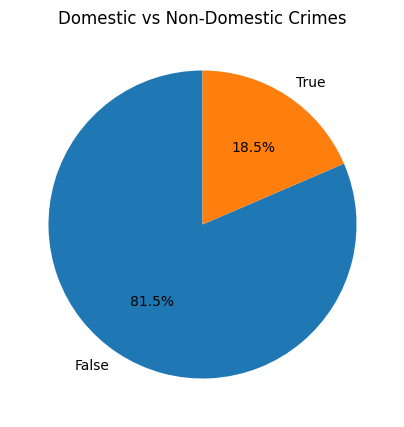

In [38]:
# Arrest ratio
plt.figure(figsize=(5,5))
df['arrest'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Arrest vs Non-Arrest Cases")
plt.ylabel("")
plt.show()

# Domestic incidents
plt.figure(figsize=(5,5))
df['domestic'].value_counts().plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Domestic vs Non-Domestic Crimes")
plt.ylabel("")
plt.show()


Crimes by Community Area

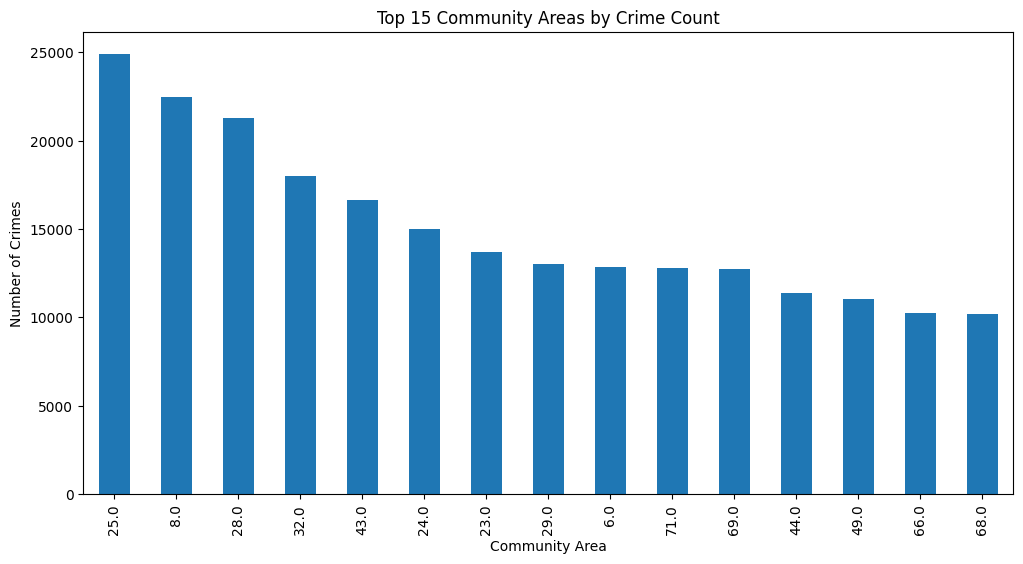

In [39]:
plt.figure(figsize=(12,6))
df['community_area'].value_counts().head(15).plot(kind='bar')
plt.title("Top 15 Community Areas by Crime Count")
plt.xlabel("Community Area")
plt.ylabel("Number of Crimes")
plt.show()


Temporal Trends by Day and Hour

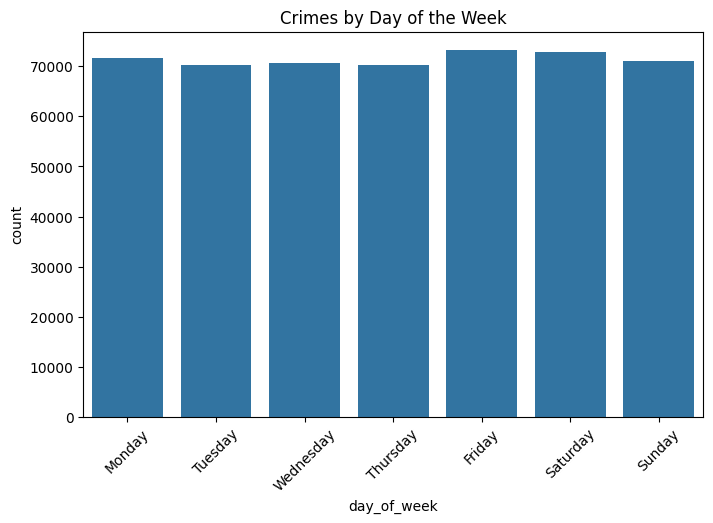

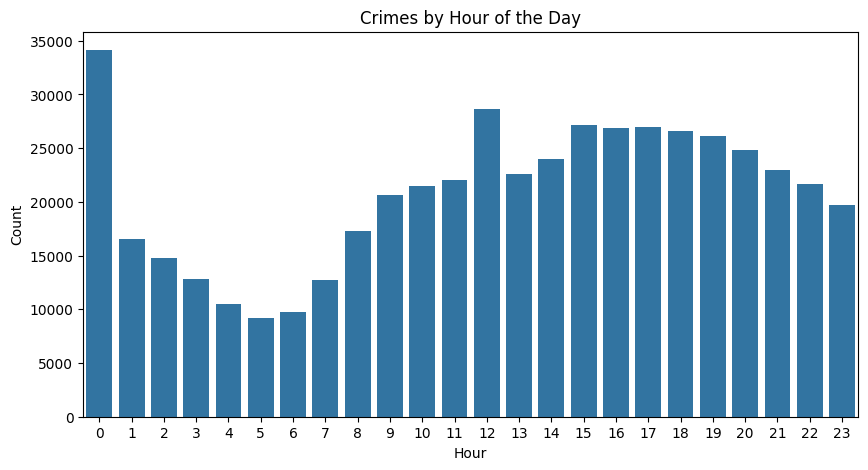

In [40]:
df['day_of_week'] = pd.to_datetime(df['date']).dt.day_name()
df['hour'] = pd.to_datetime(df['date']).dt.hour

# Day of week
plt.figure(figsize=(8,5))
sns.countplot(x='day_of_week', data=df, order=['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
plt.title("Crimes by Day of the Week")
plt.xticks(rotation=45)
plt.show()

# Hour of day
plt.figure(figsize=(10,5))
sns.countplot(x='hour', data=df)
plt.title("Crimes by Hour of the Day")
plt.xlabel("Hour")
plt.ylabel("Count")
plt.show()


Correlation Heatmap (for Numeric Columns)

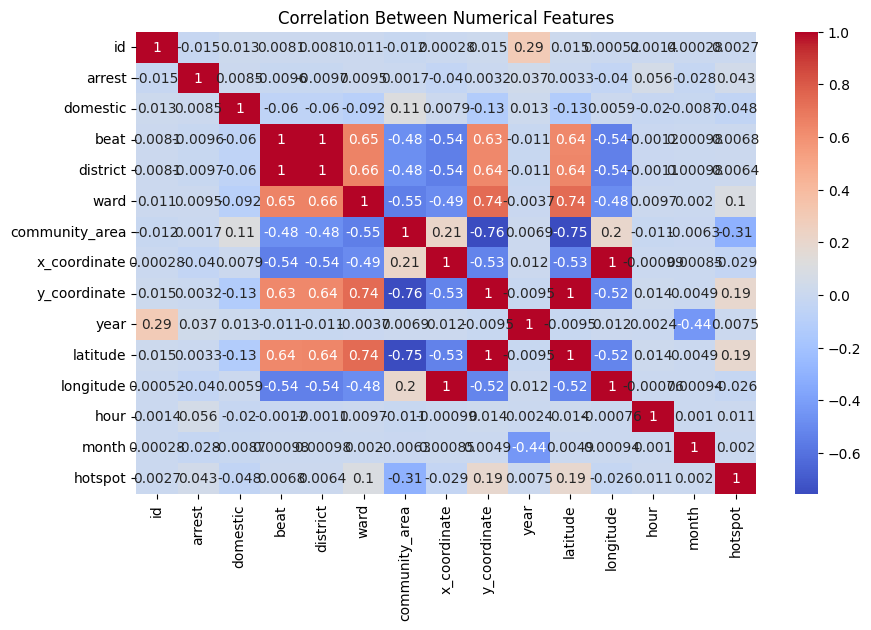

In [41]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title("Correlation Between Numerical Features")
plt.show()


Geospatial Visualization

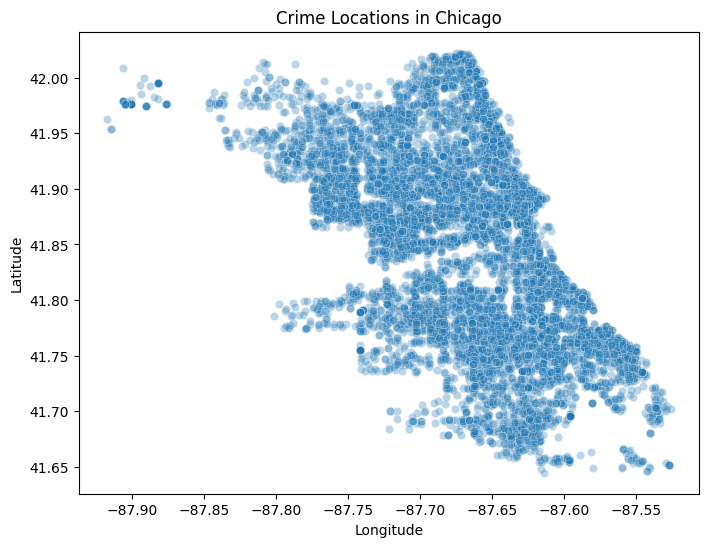

In [42]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='longitude', y='latitude', data=df.sample(10000), alpha=0.3)
plt.title("Crime Locations in Chicago")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()


summary

Crimes peaked in 2022 and are slightly declining after that.

Most frequent crimes: Theft, Battery, and Criminal Damage.

Hotspots: South and West Chicago areas.

Crimes are most common in summer and weekends, especially at night.

Arrests occur in roughly X% of cases.